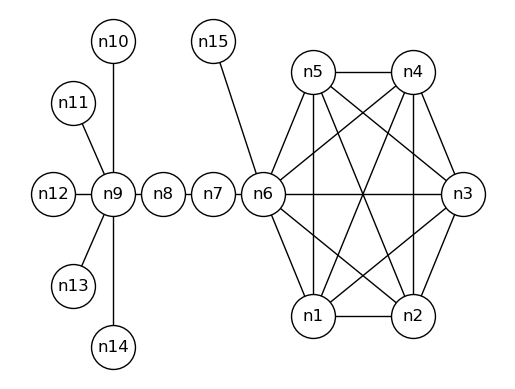

In [34]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create empty undirected graph
G = nx.Graph()


clique_nodes = [f"n{i}" for i in range(1, 6)]
for i in range(len(clique_nodes)):
    for j in range(i+1, len(clique_nodes)):
        G.add_edge(clique_nodes[i], clique_nodes[j])

G.add_edges_from([
    ("n7", "n8"),
    ("n8", "n9"),
    ("n6", "n15"),
    ("n6", "n1"), 
    ("n6", "n2"), 
    ("n6", "n3"),
    ("n6", "n4"), 
    ("n6", "n5"), 
    ("n6", "n7")
])

for i in range(10, 15):
    G.add_edge("n9", f"n{i}")


# ======== DRAWING ========
# Define coordinates to match the layout in your image
pos = {
    "n1": (2.0, -0.4),
    "n2": (3, -0.4),
    "n3": (3.5, 0.0),
    "n4": (3, 0.4),
    "n5": (2.0, 0.4),
    "n6": (1.5, 0.0),
    "n7": (1.0, 0.0),
    "n8": (0.5, 0.0),
    "n9": (0.0, 0.0),
    "n10": (0.0, 0.5),
    "n11": (-0.4, 0.3),
    "n12": (-0.6, 0.0),
    "n13": (-0.4, -0.3),
    "n14": (0.0, -0.5),
    "n15": (1.0, 0.5)
}

# Draw nodes and labels
nx.draw_networkx_nodes(G, pos, node_color="white", edgecolors="black", node_size=1000)
nx.draw_networkx_labels(G, pos)

# Draw edges
nx.draw_networkx_edges(G, pos, width=1, edge_color="black")

plt.axis("off")
plt.show()


#### 2.A) Compute the Katz centrality, with β = 0.15 and uniform intrinsic centrality µ. You can implement the computation in Matlab, Python or whatever language you prefer.

the Katz centrality is defined as:

$$
z = \frac{1 - \beta}{\lambda_W} W' z + \beta \mu, \quad \beta \in [0,1],
$$

where $W'$ is the transpose of the adjacency matrix, $\beta$ is a parameter that balances the weight between intrinsic and network-based centrality, $\mu$ is the vector of intrinsic centralities (assumed uniform in this case), and $\lambda_W$ is the **spectral radius** of $W$, i.e., its largest eigenvalue.

When $\beta = 0$, the expression reduces to the eigenvector centrality, since all centrality derives purely from the network connections.  
When $\beta = 1$, instead, we obtain $z = \mu$, meaning that each node retains only its intrinsic centrality.

The Katz centrality can be computed using either a **direct** or an **iterative** approach.  
Direct methods are based on matrix inversion, which becomes computationally expensive for large networks.  
Starting from the first equation, we can write:

$$
z(I- \frac{1 - \beta}{\lambda_W} W') = \beta \mu, \\
z = \beta (I-\frac{1 - \beta}{\lambda_W} W')^{-1}\mu, \\
A = \frac{1 - \beta}{\lambda_W} W' 
\;\;\Rightarrow\;\;
\rho(A) = \frac{1 - \beta}{\lambda_W}\,\rho(W) = 1 - \beta<1
$$

Since $\rho(A)$ is smaller than one, we can apply the **Neumann series expansion**:

$$
(I-\frac{1 - \beta}{\lambda_W} W')^{-1} = \sum_{k=0}^{\inf}(\frac{1 - \beta}{\lambda_W})^k(W')^k
$$

and obtain:

$$
z = \beta \sum_{k=0}^{\inf}(\frac{1 - \beta}{\lambda_W})^k(W')^k \mu\\

$$

Let $a = \dfrac{1 - \beta}{\lambda_W}$, and define $z^{(k)}$ and $z^{(k+1)}$ as follows:

$$
\begin{aligned}
z^{(k)} 
&= \beta \sum_{i=0}^{k} a^{\,i} (W')^{i}\,\mu \\[6pt]
z^{(k+1)} 
&= \beta \sum_{i=0}^{k+1} a^{\,i} (W')^{i}\,\mu \\[6pt]
&= \beta\Big( a^{\,0}(W')^{0}\mu \;+\; \sum_{i=1}^{k+1} a^{\,i} (W')^{i}\mu \Big) \\[6pt]
&= \beta\mu \;+\; \beta \sum_{i=1}^{k+1} a^{\,i} (W')^{i}\mu \\[6pt]
&= \beta\mu \;+\; \beta\,a\,W' \sum_{i=1}^{k+1} a^{\,i-1} (W')^{i-1}\mu \\[6pt]
&= \beta\mu \;+\; \beta\,a\,W' \sum_{j=0}^{k} a^{\,j} (W')^{j}\mu \qquad (j=i-1) \\[6pt]
&= \beta\mu \;+\; a\,W'\,\Big( \beta \sum_{j=0}^{k} a^{\,j} (W')^{j}\mu \Big) \\[6pt]
&= \beta\mu \;+\; a\,W'\,z^{(k)}
\end{aligned}
$$

$$
\boxed{\,z^{(k+1)} \;=\; \frac{1-\beta}{\lambda_W}\,W'\,z^{(k)} \;+\; \beta\,\mu\,}
$$

Hence, the **iterative method** updates the centrality vector over time according to the following dynamics:

$$
\begin{cases}
z(t+1) = \frac{1 - \beta}{\lambda_W} W' z(t) + \beta \mu, \\
z(0) = z_0.
\end{cases}
$$

This iterative process converges to the Katz centrality and is generally more efficient. However, it is not fully distributed, since each node must know $\lambda_W$, which is a **global property** of the network.


In [36]:
N = G.number_of_nodes()
beta = 0.15
mu = np.ones((N,1))/N

# arbitrary initial condition: 1/N-uniform vector of size N (initial condition does not matters)
z_0 = np.ones((N,1))/N

# set a tolerance to assess convergence to the limit
tol = 1e-5

# run the dynamics, initialize z
z_old = z_0

# Compute W
W = nx.adjacency_matrix(G)
W = W.toarray()

# Compute radius
eval, evec = np.linalg.eig(W)
eval = eval.real
radius = np.max(eval)


print("Radius of matrix W:"+str(radius))

while True:
    # Define update rule of z
    z_new = W.T @ z_old * (1-beta)/radius + beta * mu
    if np.linalg.norm(z_new-z_old) < tol:
        break
    z_old=z_new

zk_distr = z_new

# normalize the centrality
zk_distr = zk_distr / sum(zk_distr)

print("Katz centrality: \n", zk_distr)


Radius of matrix W:5.071061467321912
Katz centrality: 
 [[0.11813757]
 [0.11813757]
 [0.11813757]
 [0.11813757]
 [0.11813757]
 [0.04424685]
 [0.03172152]
 [0.04281285]
 [0.13007854]
 [0.03892977]
 [0.02430452]
 [0.02430452]
 [0.02430452]
 [0.02430452]
 [0.02430452]]


#### 2.B) Write a distributed algorithm for the computation of Page-rank centrality, with β = 0.15 and uniform intrinsic centrality µ

The **PageRank centrality** can be derived from the steady-state solution of the following equation:

$$
z = (\mathbf{I} - (1-\beta) P')^{-1} \beta \mu
$$

where $P'$ is the transpose of the stochastic transition matrix $P$, $\beta = 0.15$ is the damping factor representing the probability of random teleportation, and $\mu$ is the intrinsic centrality vector, assumed uniform (i.e., $\mu = \frac{1}{N}\mathbf{1}$).

Instead of computing the inverse matrix explicitly, which is computationally expensive for large graphs, PageRank can be efficiently obtained through the following **iterative dynamics**:

$$
\begin{cases} 
z(t+1) = (1-\beta) P' z(t) + \beta \mu, \\
z(0) = z_0.
\end{cases}
$$

At each iteration, the centrality value of a node is updated as a weighted combination of the contributions from its incoming neighbors and network intrinsic component $\beta \mu$.  
This process converges to the PageRank vector $z^*$.

Unlike the iterative algorithm used for **Katz centrality**, this procedure is **distributed**, since each node only needs information from its **incoming neighbors** to update its own value.  
In particular, no global information—such as the spectral radius $\lambda_W$ required in the Katz case—is needed.  
Therefore, the PageRank computation can be performed **locally and asynchronously**, making it well-suited for large-scale and decentralized networks.


In [ ]:
N = G.number_of_nodes()
beta = 0.15
mu = np.ones((N,1))/N

# Compute matrix P= D^-1 @ W where D is diagonal degree matrix
degrees = np.sum(W,axis=1)
D = np.diag(degrees)
P = np.linalg.inv(D) @ W

# arbitrary initial condition: 1/N-uniform vector of size N (initial condition does not matters)
z_0 = np.ones((N,1))/N

# set a tolerance to assess convergence to the limit
tol = 1e-5

# run the dynamics
z_old = z_0

while True:
    # Update rule
    z_new = P.T @ z_old * (1-beta) + beta * mu
    # When |z^{k+1}-z^{k}|< tollerance stop iterating, we have already found an acceptable solution
    if np.linalg.norm(z_new-z_old) < tol:
        break
    z_old=z_new

zb_distr = z_new

# normalize the centrality
zb_distr = zb_distr / sum(zb_distr)

print("Bonacich centrality: \n", zb_distr)

Bonacich centrality: 
 [[0.07467977]
 [0.07467977]
 [0.07467977]
 [0.07467977]
 [0.07467977]
 [0.04861054]
 [0.05815016]
 [0.19404103]
 [0.11445073]
 [0.0238975 ]
 [0.03749024]
 [0.03749024]
 [0.03749024]
 [0.03749024]
 [0.03749024]]


#### 2.C)Explain the results of points (a) and (b), focusing on the centralities of nodes n6 and n9

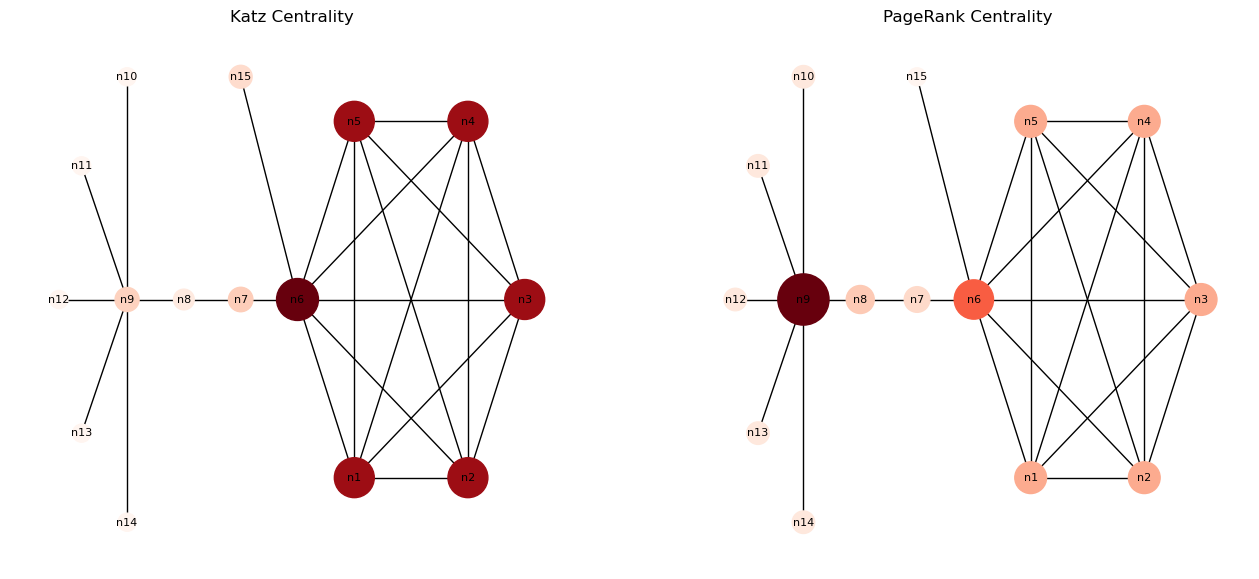

In [41]:
# reshape the centrality vectors
zk_reshape = zk_distr.reshape(N)
zb_reshape = zb_distr.reshape(N)

# node size proportional to Katz centrality
nodesize_k = zk_reshape * 7000
# node size proportional to PageRank centrality
nodesize_b = zb_reshape * 7000

# create a figure with two side-by-side subplots
plt.figure(figsize=(16, 7))

# --- Katz centrality ---
plt.subplot(1, 2, 1)
nx.draw(
    G, pos,
    with_labels=True,
    nodelist=list(G.nodes()),
    node_size=nodesize_k,
    node_color=zk_reshape,
    cmap=plt.cm.Reds,
    font_size=8
)
plt.title("Katz Centrality", fontsize=12)

# --- PageRank centrality ---
plt.subplot(1, 2, 2)
nx.draw(
    G, pos,
    with_labels=True,
    nodelist=list(G.nodes()),
    node_size=nodesize_b,
    node_color=zb_reshape,
    cmap=plt.cm.Reds,
    font_size=8
)
plt.title("PageRank Centrality", fontsize=12)

# display both graphs
plt.show()


Considering the Neumann series expansions for the two centralities, we have:

$$
z_{\text{Katz}} = \beta \sum_{k=0}^{\infty}\left(\frac{1 - \beta}{\lambda_W}\right)^k (W')^k \mu,
\qquad
z_{\text{PageRank}} = \beta \sum_{k=0}^{\infty}(1 - \beta)^k (P')^k \mu.
$$

Let us focus on a single node $i$. Its Katz centrality can be written as:

$$
z_{i,\text{Katz}} = \beta \sum_{k=0}^{\infty}\sum_{j}\left(\frac{1 - \beta}{\lambda_W}\right)^k (W')^{k}_{ij}\,\mu_j.
$$

Since $(W')^{k}_{ij}$ represents the number of walks of length $k$ from node $j$ to node $i$, the Katz centrality of node $i$ can be interpreted as the weighted sum of all possible paths ending at node $i$. The term $k=0$ corresponds to its intrinsic centrality $\mu_i$, while $k=1$ adds the contribution from its direct in-neighbors, i.e., $\sum_j W_{ji}\mu_j$, and higher-order terms account for nodes connected by longer paths. Each additional step is discounted by the attenuation factor $\left(\frac{1-\beta}{\lambda_W}\right)^k$, meaning that longer paths contribute less to the total score. As a result, Katz centrality captures the cumulative influence of all nodes that can reach $i$, weighted by path length.

From this expression, it follows that nodes belonging to highly connected regions of the graph—where there are many direct and indirect walks—will accumulate larger centrality values. In our network, node $n6$ attains the highest Katz centrality because it belongs to the fully connected subgraph on the right (nodes $n1$–$n6$), where the number of possible walks between nodes is extremely large. Conversely, node $n9$ has a lower score because it is mostly connected to less influential, isolated nodes, resulting in fewer paths from other nodes to $n9$.

For PageRank, the reasoning is similar but the interpretation differs because the weights derive from the stochastic transition matrix $P$. For node $i$, we have:

$$
z_{i,\text{PR}} = \beta \sum_{k=0}^{\infty}(1 - \beta)^k \sum_{j} (P')^{k}_{ij}\,\mu_j.
$$

Here, $(P')^{k}_{ij}$ represents the probability that a random walker starting from node $j$ reaches node $i$ in $k$ steps, following the network’s link structure where each outgoing edge from $j$ is weighted by $1/\text{outdeg}(j)$. Therefore, the centrality of node $i$ is the sum of the probabilistic flows arriving from all nodes $j$, discounted by $(1 - \beta)^k$ to account for the teleportation probability $\beta$. In this case, nodes that receive many incoming links from important nodes with low out-degree tend to accumulate higher scores.

In our graph, node $n9$ achieves the highest PageRank centrality because it receives several incoming links from the peripheral nodes on the left, each of which has out-degree one. These nodes transfer all their probability mass directly to $n9$, concentrating importance on it. On the other hand, the nodes in the dense right-hand subgraph distribute their probability among many neighbors, which dilutes their individual contributions. Hence, while Katz centrality emphasizes nodes embedded in densely connected regions with many walks, PageRank emphasizes nodes that act as sinks of incoming influence, receiving concentrated importance from their neighbors.


#### 2.D)Compute the Page-Rank centrality with uniform intrinsic centrality $µ$ and for every$$\beta \in \{0,\frac{1}{4},\frac{2}{4},\frac{3}{4},1\} $$Is the difference between the centrality of node n6 and node n9 monotone in $\beta$? Explain the results, focusing in particular on the extreme values of $\beta$.

PageRank(n6) by β: {0.0: 0.14583333314650243, 0.25: 0.11060448733354618, 0.5: 0.1014039855648732, 0.75: 0.0875066384293296, 1.0: 0.06666666666666668}
PageRank(n9) by β: {0.0: 0.12500000203847736, 0.25: 0.19111593628125947, 0.5: 0.16669254589170562, 0.75: 0.1269777278005939, 1.0: 0.06666666666666668}
z[n6]-z[n9] by β: {0.0: 0.02083333110802507, 0.25: -0.0805114489477133, 0.5: -0.06528856032683242, 0.75: -0.03947108937126431, 1.0: 0.0}
Difference z[n6]-z[n9] is NOT monotone in β.


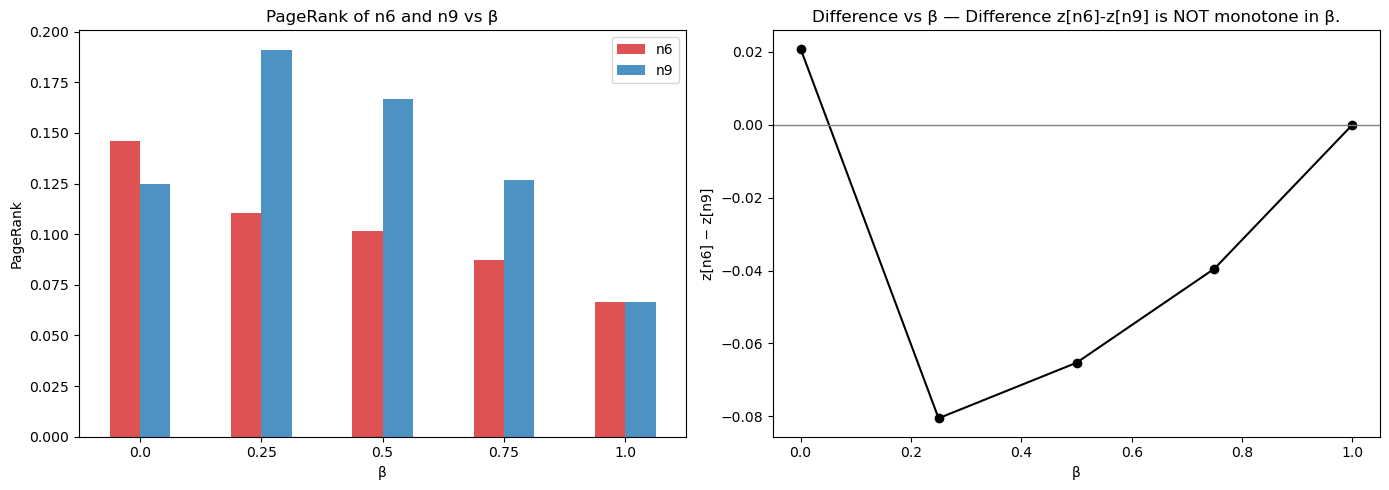

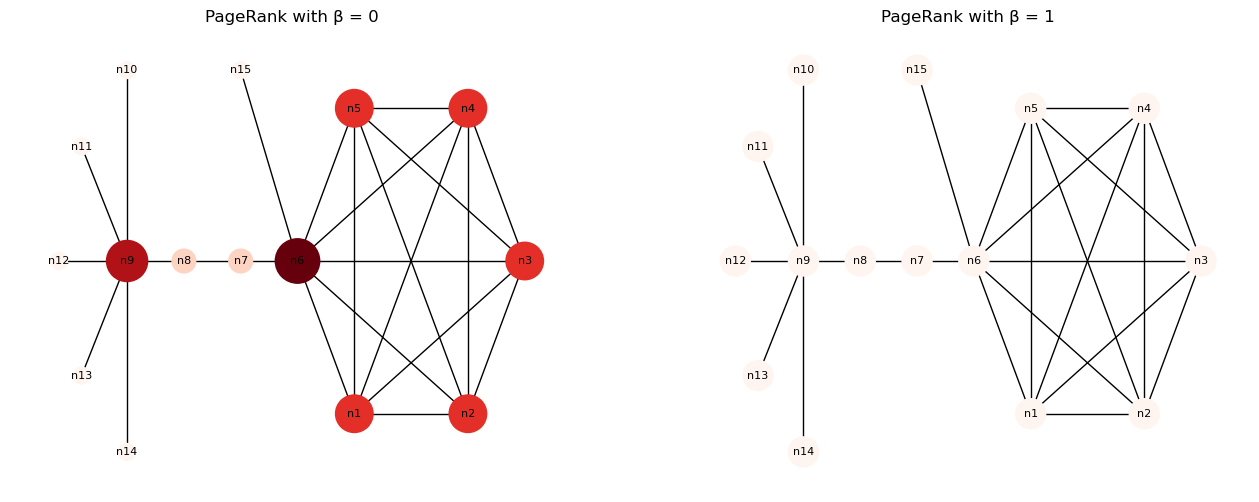

In [44]:

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# --- Helper: iterative PageRank solver with uniform μ ---
# Solves z = (1-β) P^T z + β μ by fixed-point iteration.
# - P must be row-stochastic (rows sum to 1)
# - μ must be a probability vector (sum to 1)
def pagerank_iterative(P, beta, mu, tol=1e-8, max_iter=10000):
    # Closed form for β=1: pure teleportation → z = μ
    if beta == 1.0:
        return mu.reshape(-1, 1)
    N = len(mu)
    z_old = np.ones((N, 1)) / N  # arbitrary uniform start
    for _ in range(max_iter):
        z_new = (1 - beta) * (P.T @ z_old) + beta * mu.reshape(N, 1)
        if np.linalg.norm(z_new - z_old, ord=1) < tol:
            return z_new
        z_old = z_new
    return z_old  # should have converged by now

# --- Build the row-stochastic transition matrix P from W computed earlier ---
# For undirected graphs: P = D^{-1} W (random walk that normalizes by node degree)
degrees = np.sum(W, axis=1)
P = W / degrees[:, None]

# --- Define the β grid and the uniform intrinsic centrality μ ---
betas = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
N = G.number_of_nodes()
mu = np.ones((N,)) / N

# --- Map node labels to indices and prepare containers for results ---
nodes = list(G.nodes())
idx_n6 = nodes.index("n6")
idx_n9 = nodes.index("n9")
pr_results = {}   # beta → PageRank vector
n6_vals, n9_vals, diff_vals = [], [], []

# --- Compute PageRank for each β and collect z[n6], z[n9], and their difference ---
for b in betas:
    z = pagerank_iterative(P, b, mu)
    z = (z / z.sum()).reshape(-1)  # normalize for numerical cleanliness
    pr_results[b] = z
    n6_vals.append(float(z[idx_n6]))
    n9_vals.append(float(z[idx_n9]))
    diff_vals.append(float(z[idx_n6] - z[idx_n9]))

# --- Check whether the difference z[n6] - z[n9] is monotone in β ---
diff_vals = np.array(diff_vals)
eps = 1e-12
is_nondec = np.all(np.diff(diff_vals) >= -eps)
is_noninc = np.all(np.diff(diff_vals) <=  eps)
if is_nondec and not is_noninc:
    monotone_msg = "Difference z[n6]-z[n9] is non-decreasing in β."
elif is_noninc and not is_nondec:
    monotone_msg = "Difference z[n6]-z[n9] is non-decreasing in β."  # keep consistent wording
    monotone_msg = "Difference z[n6]-z[n9] is non-increasing in β."
elif is_nondec and is_noninc:
    monotone_msg = "Difference z[n6]-z[n9] is constant in β."
else:
    monotone_msg = "Difference z[n6]-z[n9] is NOT monotone in β."

print("PageRank(n6) by β:", dict(zip(betas, n6_vals)))
print("PageRank(n9) by β:", dict(zip(betas, n9_vals)))
print("z[n6]-z[n9] by β:", dict(zip(betas, diff_vals)))
print(monotone_msg)

# --- Plot 1: PR(n6) and PR(n9) vs β + difference curve ---
# --- Improved Plot 1: grouped bars for n6 and n9 per β, and difference curve side-by-side ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ===== Left subplot: grouped bars =====
centers = np.arange(len(betas))
group_width = 0.6      # total width reserved for each β group (space between groups)
bar_width   = 0.25     # slim bars inside each group
offset      = bar_width / 2

# bar positions
x_n6 = centers - offset
x_n9 = centers + offset

# plot bars
ax[0].bar(x_n6, n6_vals, width=bar_width, label="n6", color="tab:red", alpha=0.8)
ax[0].bar(x_n9, n9_vals, width=bar_width, label="n9", color="tab:blue", alpha=0.8)

# labels and formatting
ax[0].set_xlabel("β")
ax[0].set_ylabel("PageRank")
ax[0].set_title("PageRank of n6 and n9 vs β")
ax[0].set_xticks(centers)
ax[0].set_xticklabels(betas)
ax[0].set_xlim(-0.5, len(betas) - 0.5)
ax[0].legend()

# ===== Right subplot: difference curve =====
ax[1].plot(betas, diff_vals, marker="o", color="black")
ax[1].axhline(0.0, color="gray", linewidth=1)
ax[1].set_xlabel("β")
ax[1].set_ylabel("z[n6] − z[n9]")
ax[1].set_title(f"Difference vs β — {monotone_msg}")

plt.tight_layout()
plt.show()


# --- Plot 2: network views for extreme β (0 and 1) to support the explanation ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
nodesize_0 = 7000 * pr_results[0.0]
nx.draw(G, pos, with_labels=True, nodelist=nodes, node_size=nodesize_0,
        node_color=pr_results[0.0], cmap=plt.cm.Reds, font_size=8)
plt.title("PageRank with β = 0")
plt.axis("off")

plt.subplot(1, 2, 2)
nodesize_1 = 7000 * pr_results[1.0]
nx.draw(G, pos, with_labels=True, nodelist=nodes, node_size=nodesize_1,
        node_color=pr_results[1.0], cmap=plt.cm.Reds, font_size=8)
plt.title("PageRank with β = 1")
plt.axis("off")
plt.show()



From the plots, it is evident that the difference between the PageRank centralities of nodes $n6$ and $n9$ is not monotone in $\beta$. For $\beta = 0$, node $n6$ has a higher centrality value than $n9$, while for $\beta$ between $0.25$ and $0.5$ this relationship reverses, with $n9$ becoming more central. As $\beta$ increases further toward $1$, the two values gradually converge until they become identical for $\beta = 1$, where every node reaches the same centrality value. The curve on the right confirms this behavior: the difference $z[n6] - z[n9]$ starts positive, becomes negative for intermediate $\beta$, and returns to zero for $\beta = 1$. The network visualizations reinforce this interpretation: when $\beta = 0$, the darker nodes are those in the dense connected component on the right, especially $n6$, while when $\beta = 1$, all nodes appear uniform, indicating that teleportation dominates and the centrality distribution becomes flat.

Mathematically, the PageRank centrality is given by  

$$
z = (1-\beta)P'z + \beta\mu = \beta\sum_{k=0}^{\infty}(1-\beta)^k (P')^{k}\mu,
$$  

where $(P')^{k}_{ij}$ represents the probability that a random walker starting from node $j$ reaches node $i$ in $k$ steps. For small $\beta$, the teleportation term $\beta\mu$ is negligible, so the result is dominated by the random-walk component $(1-\beta)P'z$. In the limiting case $\beta = 0$, PageRank reduces to  

$$
z = P'z,
$$  

which corresponds to the stationary distribution of the simple random walk. For undirected graphs, this is proportional to node degree,  

$$
z_i = \frac{\deg(i)}{\sum_j \deg(j)}.
$$  

Hence, nodes with higher degree—like $n6$, which belongs to the dense subgraph on the right—receive higher centrality. Node $n9$, despite being a hub for several leaves, has lower degree and fewer reciprocal connections, so it obtains a smaller score. This behavior at $\beta = 0$ mirrors the effect of the Katz centrality: in fact, the Katz dynamics  

$$
z = \frac{1-\beta}{\lambda_W}W'z + \beta\mu,
$$  

reduces to  

$$
W'z = \lambda_W z
$$  

when $\beta = 0$, which is precisely the eigenvector centrality. In our graph, the eigenvector centrality and the random-walk stationary distribution are strongly correlated, because the dense right-hand component dominates both measures. This explains why the PageRank for $\beta = 0$ and the Katz centrality show similar patterns.

When $\beta$ increases, the teleportation term $\beta\mu$ gains importance, introducing an external uniform influence that progressively equalizes centrality values. At intermediate $\beta$ values (around $0.25$–$0.5$), node $n9$ becomes more central because of the probabilistic nature of PageRank: its many leaves each have out-degree $1$ and transfer their entire probability mass to $n9$, while nodes in the right-hand clique, including $n6$, divide their mass among several neighbors. As a result, $n9$ absorbs more incoming probability and its PageRank surpasses that of $n6$. As $\beta$ approaches $1$, teleportation dominates completely, and  

$$
z \to \mu,
$$  

meaning all nodes share the same uniform value and the difference $z[n6] - z[n9]$ converges to zero. Therefore, the non-monotonicity of the difference arises from the competition between two effects: the random-walk term that favors structurally central nodes like $n6$, and the out-degree normalization that benefits nodes such as $n9$ receiving concentrated inbound probability from low-degree neighbors. At the extremes, $\beta = 0$ reproduces a Katz-like, degree-based ranking, while $\beta = 1$ yields uniform centrality across the network.
